# SST 谱特征：逐点统计与信息时刻

本单元读取已有复谱，提取频率分布、集中程度和相位一致性，用于比较不同采样点的振荡结构。它不重新计算小波、不估计模型、不使用后续采样点。频率单位为 cycles_per_sample；主周期单位为采样点。

`compute_spectral_features` 接收 time×bin 复谱及固定 SST 网格，返回特征表、相对谱质量和参数；`extract_sst_features` 接收 c03 序列表，将坐标、上游状态和可得时刻接到特征上；`build_spectral_feature_schema` 定义局部 Arrow 契约；`plot_spectral_features` 只读取已有特征表，按 `plot_type` 绘制一张图。

质心与扩散采用频率加权均值和标准差，可选择幅值或功率权重，定义参见 [MathWorks 谱描述符](https://www.mathworks.com/help/audio/ug/spectral-descriptors.html)。相位一致性采用单位相位向量的加权合向量长度，是 [圆周统计的平均合向量长度](https://docs.scipy.org/doc/scipy-1.17.0/reference/generated/scipy.stats.circvar.html)的加权形式；它描述当前频率区间之间的相位排列，不证明谐波关系或时间稳定性。

In [1]:
from pathlib import Path
import sys
project_markers = [".git", ".env", "config/settings.py"]
current_path = Path.cwd().resolve()
for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        break
else:
    raise RuntimeError("未找到项目根目录")


## 数值定义与参数

设复谱为 $T_j$，幅值 $A_j=|T_j|$，频率区间中心为 $f_j$。`bin_weighting='frequency_width'` 默认取 $v_j=\Delta f_j$；`equal` 取 $v_j=1$，用于按区间求和的比较。功率质量为 $E_j=A_j^2v_j$，相对质量为 $p_j=E_j/\sum E_j$。这里的 `total_energy` 是复谱平方范数，不等于原收益率序列的能量，SST 不保证 Parseval 能量守恒。

`moment_weight='amplitude'` 默认使用 $q_j=A_jv_j/\sum A_jv_j$；`power` 使用 $q_j=p_j$。质心为 $\mu=\sum q_jf_j$，扩散为 $\sigma=\sqrt{\sum q_j(f_j-\mu)^2}$，偏度为标准化三阶中心矩，峰度为标准化四阶中心矩减 3。峰值占比为 $\max p_j$，熵为 $-\sum_{p_j>0}p_j\log p_j$，不对零概率加 epsilon。主频为最大功率**密度**的区间中心，平峰取最低频率；主周期为其倒数。

高／低频按区间中心比较 `split_frequency`，低频为 $f_j<\mathrm{cut}$，等于切点归高频；默认切点是整个频率范围端点的算术中点。切点与整个区间相交时仍按中心划分，不进行区间内插值。比值为两侧功率质量之比。有效频率数使用功率密度严格大于当前最大密度乘 `effective_power_ratio`，默认 0.01，此参数独立于上游 SST 系数阈值。带宽由 `bandwidth_quantiles` 决定，默认 5%—95%；中位频率为 50% 分位，四分位距为 25%—75%。分位数取频率中心的离散逆 CDF，不在区间内部插值。

相位一致性为 $|\sum q_j e^{i\arg T_j}|$，使用同一 `moment_weight`；零幅值不提供相位。±π 附近的相位按同一方向处理。

In [2]:
import hashlib
import json
import numpy as np
import pandas as pd
import pyarrow as pa
from config.data_contracts import pandas_to_arrow
from R04_Research.a01_Methods.b06_WaveletAnalysis.c02_Synchrosqueezing import (
    SSTFrequencyGrid, build_sst_frequency_grid,
)

SPECTRAL_FEATURE_VERSION = '0.1.0'
SPECTRAL_FEATURE_NAMES = (
    'centroid', 'spread', 'dominant_freq', 'dominant_period_samples',
    'peak_energy_ratio', 'spectral_entropy', 'high_low_energy_ratio',
    'skewness', 'kurtosis', 'phase_coherence', 'effective_freq_count',
    'spectral_bandwidth', 'median_freq', 'iqr_freq',
    'total_energy', 'low_freq_energy', 'high_freq_energy',
)
SPECTRAL_COORDINATE_FIELDS = [
    pa.field('sample_id', pa.int64()),
    *[pa.field(name, pa.timestamp('us', tz='Asia/Shanghai')) for name in
      ['sample_at', 'bar_at']],
    pa.field('trading_date', pa.date32()), pa.field('sample_side', pa.string()),
    pa.field('is_causal', pa.bool_()),
    *[pa.field(name, pa.timestamp('us', tz='Asia/Shanghai')) for name in
      ['input_available_at', 'available_at', 'analysis_context_end_at', 'feature_available_at']],
    pa.field('sst_status', pa.string()), pa.field('sst_reason', pa.string()),
]

def compute_spectral_features(spectrum, frequency_grid: SSTFrequencyGrid, *,
        spectrum_status=None, spectrum_reason=None, bin_weighting='frequency_width',
        moment_weight='amplitude', split_frequency=None, effective_power_ratio=0.01,
        bandwidth_quantiles=(0.05, 0.95), partial_policy='allow') -> dict:
    """逐行计算复谱统计，不跨点聚合。零分母和数值失败逐字段记录，不填值。"""
    if not isinstance(frequency_grid, SSTFrequencyGrid):
        raise ValueError('frequency_grid 必须为 SSTFrequencyGrid')
    edges = frequency_grid.edges
    frequencies = (edges[:-1]+edges[1:])/2
    widths = np.diff(edges)
    spectrum_values = np.asarray(spectrum, dtype=complex)
    if spectrum_values.ndim == 1:
        spectrum_values = spectrum_values[None, :]
    if spectrum_values.ndim != 2 or spectrum_values.shape[1] != len(frequencies):
        raise ValueError('复谱须为 time×bin，列数与固定网格一致')
    if bin_weighting not in ('frequency_width', 'equal'):
        raise ValueError('bin_weighting 必须为 frequency_width 或 equal')
    if moment_weight not in ('amplitude', 'power'):
        raise ValueError('moment_weight 必须为 amplitude 或 power')
    if partial_policy not in ('allow', 'exclude'):
        raise ValueError('partial_policy 必须为 allow 或 exclude')
    if not np.isscalar(effective_power_ratio) or np.iscomplexobj(effective_power_ratio) or not np.isfinite(effective_power_ratio) or effective_power_ratio < 0:
        raise ValueError('effective_power_ratio 必须为有限非负实数')
    if split_frequency is not None and (not np.isscalar(split_frequency) or np.iscomplexobj(split_frequency)):
        raise ValueError('split_frequency 必须为有限实数')
    cut = float((edges[0]+edges[-1])/2 if split_frequency is None else split_frequency)
    if not np.isfinite(cut) or not edges[0] < cut < edges[-1]:
        raise ValueError('split_frequency 必须严格位于网格频率范围内')
    if np.iscomplexobj(bandwidth_quantiles):
        raise ValueError('带宽分位参数必须为实数')
    quantiles = np.asarray(bandwidth_quantiles, dtype=float)
    if quantiles.shape != (2,) or not np.isfinite(quantiles).all() or not 0 <= quantiles[0] < quantiles[1] <= 1:
        raise ValueError('bandwidth_quantiles 必须满足 0 <= lower < upper <= 1')
    point_count = len(spectrum_values)
    upstream_status = np.full(point_count, 'ok', dtype=object) if spectrum_status is None else np.asarray(spectrum_status, dtype=object)
    upstream_reason = np.full(point_count, '', dtype=object) if spectrum_reason is None else np.asarray(spectrum_reason, dtype=object)
    if upstream_status.shape != (point_count,) or upstream_reason.shape != (point_count,):
        raise ValueError('上游点状态和原因须与复谱行数一致')
    if not np.isin(upstream_status, ['ok', 'partial', 'warmup', 'boundary_incomplete', 'failed']).all():
        raise ValueError('未知 SST 点状态')
    parameters = dict(bin_weighting=bin_weighting, moment_weight=moment_weight,
        split_frequency=cut, effective_power_ratio=float(effective_power_ratio),
        bandwidth_quantiles=quantiles.tolist(), partial_policy=partial_policy,
        phase_definition='weighted_circular_resultant', frequency_unit='cycles_per_sample',
        quantile_definition='discrete_center_inverse_cdf', dominant_definition='power_density_lowest_frequency_tie')
    feature_values = np.full((point_count, len(SPECTRAL_FEATURE_NAMES)), np.nan)
    feature_reasons = np.full(feature_values.shape, '', dtype=object)
    feature_status = np.full(point_count, 'ok', dtype=object)
    feature_reason = np.full(point_count, '', dtype=object)
    relative_energy = np.full(spectrum_values.shape, np.nan)
    bin_weights = widths if bin_weighting == 'frequency_width' else np.ones(len(widths))
    low_mask = frequencies < cut
    for point in range(point_count):
        source_status = upstream_status[point]
        if source_status not in ('ok', 'partial'):
            feature_status[point], feature_reason[point] = source_status, 'upstream_'+str(source_status)
            feature_reasons[point, :] = feature_reason[point]
            continue
        if source_status == 'partial' and partial_policy == 'exclude':
            feature_status[point], feature_reason[point] = 'excluded', 'upstream_partial_excluded'
            feature_reasons[point, :] = feature_reason[point]
            continue
        row_spectrum = spectrum_values[point]
        with np.errstate(over='ignore', invalid='ignore'):
            amplitude = np.abs(row_spectrum)
        if not np.isfinite(row_spectrum).all() or not np.isfinite(amplitude).all():
            feature_status[point], feature_reason[point] = 'failed', 'nonfinite_spectrum'
            feature_reasons[point, :] = 'nonfinite_spectrum'
            continue
        amplitude_max = float(amplitude.max())
        if amplitude_max == 0:
            feature_status[point], feature_reason[point] = 'degenerate', 'zero_spectrum'
            feature_reasons[point, :] = 'zero_spectrum'
            for name in ('total_energy', 'low_freq_energy', 'high_freq_energy', 'effective_freq_count'):
                column = SPECTRAL_FEATURE_NAMES.index(name)
                feature_values[point, column], feature_reasons[point, column] = 0., ''
            continue
        # 先按当前幅值最大值缩放。分布统计不依赖尺度，避免直接平方溢出。
        scaled_amplitude = amplitude/amplitude_max
        scaled_density = scaled_amplitude**2
        power_mass = scaled_density*bin_weights
        probability = power_mass/power_mass.sum()
        relative_energy[point] = probability
        moment_mass = scaled_amplitude*bin_weights if moment_weight == 'amplitude' else power_mass
        moment_probability = moment_mass/moment_mass.sum()
        centroid = float(moment_probability@frequencies)
        deviation = frequencies-centroid
        variance = float(moment_probability@(deviation**2))
        spread = np.sqrt(max(variance, 0.))
        dominant = int(np.argmax(scaled_density))
        positive = probability > 0
        entropy = float(-np.sum(probability[positive]*np.log(probability[positive])))
        cdf = np.cumsum(probability)
        # 排除零质量区间；0/1 分位分别取实际支持的最小/最大中心。
        occupied = np.flatnonzero(positive)
        support_cdf = cdf[occupied]
        support_cdf[-1] = 1.
        requested_quantiles = [quantiles[0], quantiles[1], 0.5, 0.25, 0.75]
        quantile_bins = occupied[np.minimum(np.searchsorted(support_cdf, requested_quantiles, side='left'), len(occupied)-1)]
        quantile_frequencies = frequencies[quantile_bins]
        nonzero = amplitude > 0
        phase_vectors = row_spectrum[nonzero]/amplitude[nonzero]
        coherence = float(min(1., abs(np.sum(moment_probability[nonzero]*phase_vectors))))
        row_features = dict(centroid=centroid, spread=spread,
            dominant_freq=float(frequencies[dominant]), dominant_period_samples=float(1/frequencies[dominant]),
            peak_energy_ratio=float(probability.max()), spectral_entropy=entropy,
            phase_coherence=coherence,
            effective_freq_count=float(np.count_nonzero(scaled_density > float(effective_power_ratio))),
            spectral_bandwidth=float(quantile_frequencies[1]-quantile_frequencies[0]),
            median_freq=float(quantile_frequencies[2]), iqr_freq=float(quantile_frequencies[4]-quantile_frequencies[3]))
        low_mass, high_mass = float(power_mass[low_mask].sum()), float(power_mass[~low_mask].sum())
        local_reasons = {}
        if low_mass > 0:
            row_features['high_low_energy_ratio'] = high_mass/low_mass
        else:
            local_reasons['high_low_energy_ratio'] = 'zero_low_frequency_energy'
        if np.count_nonzero(moment_probability) > 1 and spread > 0:
            standardized = deviation/spread
            row_features['skewness'] = float(moment_probability@(standardized**3))
            row_features['kurtosis'] = float(moment_probability@(standardized**4)-3)
        else:
            local_reasons.update(skewness='zero_spectral_spread', kurtosis='zero_spectral_spread')
        for name, mass in [('total_energy', float(power_mass.sum())), ('low_freq_energy', low_mass), ('high_freq_energy', high_mass)]:
            if mass == 0:
                row_features[name] = 0.
            else:
                with np.errstate(over='ignore', under='ignore', invalid='ignore'):
                    norm_value = float(np.exp(2*np.log(amplitude_max)+np.log(mass)))
                if not np.isfinite(norm_value):
                    local_reasons[name] = 'nonfinite_spectral_norm'
                elif norm_value == 0:
                    local_reasons[name] = 'spectral_norm_underflow'
                else:
                    row_features[name] = norm_value
        for column, name in enumerate(SPECTRAL_FEATURE_NAMES):
            value = row_features.get(name, np.nan)
            if name in row_features and not np.isfinite(value):
                local_reasons[name] = 'nonfinite_feature'
            if name not in local_reasons:
                feature_values[point, column] = value
            feature_reasons[point, column] = local_reasons.get(name, '')
        reasons = (['upstream_partial'] if source_status == 'partial' else []) + sorted(set(local_reasons.values()))
        if reasons:
            feature_status[point], feature_reason[point] = 'partial', ';'.join(reasons)
    feature_df = pd.DataFrame(feature_values, columns=SPECTRAL_FEATURE_NAMES)
    for column, name in enumerate(SPECTRAL_FEATURE_NAMES):
        feature_df['feature_reason_'+name] = feature_reasons[:, column]
    feature_df['defined_feature_count'] = np.isfinite(feature_values).sum(axis=1).astype(np.int64)
    feature_df['feature_status'], feature_df['feature_reason'] = feature_status, feature_reason
    return dict(feature_df=feature_df, relative_energy=relative_energy,
        spectrum_status=upstream_status.copy(), spectrum_reason=upstream_reason.copy(),
        parameters=parameters, frequency_grid_signature=frequency_grid.signature)

def build_spectral_feature_schema(frequency_grid: SSTFrequencyGrid, parameters: dict) -> pa.Schema:
    """局部特征宽表；字段原因独立于上游 SST 状态。"""
    fields = [*SPECTRAL_COORDINATE_FIELDS,
        *[pa.field(name, pa.float64()) for name in SPECTRAL_FEATURE_NAMES],
        *[pa.field('feature_reason_'+name, pa.string()) for name in SPECTRAL_FEATURE_NAMES],
        pa.field('defined_feature_count', pa.int64()),
        pa.field('feature_status', pa.string()), pa.field('feature_reason', pa.string())]
    metadata = dict(method='sst_spectral_features', schema_version=SPECTRAL_FEATURE_VERSION,
        frequency_grid_signature=frequency_grid.signature,
        parameters=json.dumps(parameters, sort_keys=True, allow_nan=False))
    return pa.schema(fields, metadata={key.encode():value.encode() for key,value in metadata.items()})

def extract_sst_features(sequence_df: pd.DataFrame, frequency_grid: SSTFrequencyGrid, **feature_parameters) -> dict:
    """消费已有 c03 SST 序列表，保留行顺序、上游诊断和信息时刻。"""
    coordinate_columns = [field.name for field in SPECTRAL_COORDINATE_FIELDS if field.name != 'feature_available_at']
    spectrum_columns = [f'sst_{component}_{interval:03d}' for component in ('real','imag')
        for interval in range(len(frequency_grid.edges)-1)]
    required_columns = [*coordinate_columns, *spectrum_columns]
    missing_columns = sorted(set(required_columns)-set(sequence_df.columns))
    if missing_columns:
        raise ValueError(f'缺少 c03 SST 字段：{missing_columns}')
    bin_count = len(frequency_grid.edges)-1
    real_values = sequence_df[spectrum_columns[:bin_count]].to_numpy(dtype=float)
    imaginary_values = sequence_df[spectrum_columns[bin_count:]].to_numpy(dtype=float)
    feature_result = compute_spectral_features(real_values+1j*imaginary_values, frequency_grid,
        spectrum_status=sequence_df['sst_status'].to_numpy(), spectrum_reason=sequence_df['sst_reason'].to_numpy(),
        **feature_parameters)
    feature_df = pd.concat([sequence_df[coordinate_columns].reset_index(drop=True), feature_result['feature_df']], axis=1)
    feature_df['feature_available_at'] = feature_df['available_at'].where(
        feature_df['is_causal'] & feature_df['defined_feature_count'].gt(0))
    feature_schema = build_spectral_feature_schema(frequency_grid, feature_result['parameters'])
    feature_df = feature_df[feature_schema.names]
    return {**feature_result, 'feature_df':feature_df, 'feature_schema':feature_schema}


## 失败、退化与信息边界

`partial_policy='allow'` 默认消费上游 partial 复谱，结果也标记 partial；`exclude` 保留该行并将数值置空。这里的部分谱不能解释为完整尺度结果。上游 warmup、boundary_incomplete、failed 逐点继承，非有限的可用复谱记录本地 failed。

零谱的总平方范数、两侧范数和有效频率数为零，分布、主频和相位未定义，记录 degenerate。单一频率的扩散为零，偏度和峰度为空；低频质量为零时高低比为空。每个数值列都有 `feature_reason_<字段>`；`defined_feature_count` 是该行实际有定义的指标数量。极大／极小谱先缩放计算分布，不能表示的绝对平方范数保留数值原因，不影响可计算的比例。

特征只使用当前复谱，不增加历史拟合或滚动窗口；截取绘图范围不改变特征。`feature_available_at` 在因果输出至少有一项特征可用时继承 c03 的 `available_at`，不回移；离线 Morlet 始终为空，保留上下文终点。返回表不删去初始缺失、预热、边界或退化行。

In [3]:
SPECTRAL_FEATURE_COLUMN_LABELS = {
    'sample_id':'sample_id（采样编号）', 'sample_at':'sample_at（采样位置时刻）',
    'bar_at':'bar_at（源报价时刻）', 'trading_date':'trading_date（交易日）',
    'sample_side':'sample_side（训练或测试侧）', 'is_causal':'is_causal（是否因果）',
    'input_available_at':'input_available_at（输入可得时刻）',
    'available_at':'available_at（变换可得时刻）',
    'analysis_context_end_at':'analysis_context_end_at（分析上下文终点）',
    'feature_available_at':'feature_available_at（特征可得时刻）',
    'sst_status':'sst_status（上游复谱状态）', 'sst_reason':'sst_reason（上游复谱原因）',
    'centroid':'centroid（频谱质心）', 'spread':'spread（频谱扩散）',
    'dominant_freq':'dominant_freq（主频率）', 'dominant_period_samples':'dominant_period_samples（主周期采样点数）',
    'peak_energy_ratio':'peak_energy_ratio（峰值质量占比）', 'spectral_entropy':'spectral_entropy（频谱熵）',
    'high_low_energy_ratio':'high_low_energy_ratio（高低频质量比）',
    'skewness':'skewness（频谱偏度）', 'kurtosis':'kurtosis（频谱超额峰度）',
    'phase_coherence':'phase_coherence（圆周相位一致性）',
    'effective_freq_count':'effective_freq_count（有效频率区间数）',
    'spectral_bandwidth':'spectral_bandwidth（指定分位频谱带宽）',
    'median_freq':'median_freq（中位频率）', 'iqr_freq':'iqr_freq（频率四分位距）',
    'total_energy':'total_energy（复谱平方范数）', 'low_freq_energy':'low_freq_energy（低频平方范数）',
    'high_freq_energy':'high_freq_energy（高频平方范数）',
    'defined_feature_count':'defined_feature_count（有定义指标数）',
    'feature_status':'feature_status（特征状态）', 'feature_reason':'feature_reason（特征原因）',
}
SPECTRAL_FEATURE_COLUMN_LABELS.update({
    'feature_reason_'+name:'feature_reason_'+name+'（'+SPECTRAL_FEATURE_COLUMN_LABELS[name].split('（')[1][:-1]+'未定义原因）'
    for name in SPECTRAL_FEATURE_NAMES})


In [4]:
def plot_spectral_features(feature_df: pd.DataFrame, *, plot_type='spectral_entropy',
        sample_id_min=None, sample_id_max=None, sample_side=None, x_labels='sample_at',
        y_scale='linear', figure_size=(13,4.2), title=None):
    """只读取已有特征，每次返回一个 figure、一个 axes，不计算或保存。"""
    import matplotlib.pyplot as plt
    if plot_type not in SPECTRAL_FEATURE_NAMES:
        raise ValueError('plot_type 必须为已定义谱特征名称')
    if x_labels not in ('sample_id','sample_at','feature_available_at'):
        raise ValueError('未知横轴标签类型')
    if y_scale not in ('linear','log'):
        raise ValueError('y_scale 必须为 linear 或 log')
    if sample_side not in (None,'train','test'):
        raise ValueError('sample_side 必须为 train 或 test')
    selected_df = feature_df
    if sample_id_min is not None:
        selected_df = selected_df.loc[selected_df['sample_id'] >= sample_id_min]
    if sample_id_max is not None:
        selected_df = selected_df.loc[selected_df['sample_id'] <= sample_id_max]
    if sample_side is not None:
        selected_df = selected_df.loc[selected_df['sample_side'].eq(sample_side)]
    if selected_df.empty:
        raise ValueError('绘图范围没有采样点')
    values = selected_df[plot_type].to_numpy(dtype=float).copy()
    if y_scale == 'log':
        values[values <= 0] = np.nan
    with plt.rc_context({'font.family':['Microsoft YaHei','SimHei','DejaVu Sans'], 'axes.unicode_minus':False}):
        figure, axes = plt.subplots(figsize=figure_size, layout='constrained')
        positions = np.arange(len(selected_df))
        axes.plot(positions, values, linewidth=0.8, color='#28769d')
        axes.set_yscale(y_scale)
        tick_positions = np.unique(np.linspace(0,len(selected_df)-1,min(8,len(selected_df)),dtype=int))
        tick_values = selected_df[x_labels].iloc[tick_positions]
        tick_labels = [str(value) if x_labels == 'sample_id' else ('不可得' if pd.isna(value) else value.strftime('%Y-%m-%d')) for value in tick_values]
        axes.set_xticks(tick_positions, tick_labels)
        axes.set_xlabel(SPECTRAL_FEATURE_COLUMN_LABELS[x_labels].split('（')[1][:-1]+'（按采样点等距排列）')
        axes.set_ylabel(SPECTRAL_FEATURE_COLUMN_LABELS[plot_type].split('（')[1][:-1])
        availability_label = '因果' if selected_df['is_causal'].all() else '含离线结果'
        axes.set_title(title or 'SST 谱特征：'+SPECTRAL_FEATURE_COLUMN_LABELS[plot_type].split('（')[1][:-1]+' · '+availability_label)
        sides = selected_df['sample_side'].to_numpy()
        boundaries = np.flatnonzero((sides[1:]=='test') & (sides[:-1]=='train'))+1
        for boundary in boundaries:
            axes.axvline(boundary-0.5, color='#cc7722', linestyle='--', linewidth=1., label='训练／测试分界')
        if len(boundaries):
            axes.legend(loc='upper left',fontsize=9)
        axes.grid(alpha=0.2)
    return figure, axes


## 真实 demo：直接读取完整 SST 序列

输入精确指定 c03 两种核的 RB、N=60、time、all_contracts、log_interpolate、fixed、log_return 产物，训练请求 2010-01-01—2024-12-31，测试请求 2025-01-01—2026-09-30。完整逐点提取默认特征，额外调用纯谱入口、功率矩权重、等区间权重和 partial 排除；只验证本单元的统计关系和依赖身份，不重算上游变换。

In [5]:
import os
import platform
import inspect
import scipy
import pyarrow.parquet as pq
from datetime import datetime, timezone
from R04_Research.a01_Methods.b02_MainContinuousAdjustment.c01_MainContinuousAdjustment import arrow_content_sha256

demo_notebook_path = candidate_root/'R04_Research/a01_Methods/b06_WaveletAnalysis/c04_SpectralFeatures.ipynb'
demo_method_dir = demo_notebook_path.parent
demo_range_token = 'train20100101-20241231_test20250101-20260930'
demo_input_token = 'N60_time_all_contracts_log_interpolate_fixed_log_return'
demo_period_token = 'P8-16-32-64-128-256'
demo_kernel_tokens = dict(causal_gammatone='causal_gammatone_q4_alpha1_omega6_mem1e-6',
    morlet='morlet_sigma1_omega6_support8_none')
demo_short_kernel_tokens = dict(causal_gammatone='gammatone_q4_a1_w6_m1e-6',morlet='morlet_s1_w6_u8_none')
demo_dependency_hashes = {}
for demo_role,demo_name in [('wavelet_transform','c01_WaveletTransform'),('synchrosqueezing','c02_Synchrosqueezing'),('rolling_wavelet','c03_RollingWavelet')]:
    demo_book = json.loads((demo_method_dir/(demo_name+'.ipynb')).read_text(encoding='utf8'))
    demo_source = '\n\n'.join(''.join(c['source']) for c in demo_book['cells']
        if c['cell_type']=='code' and 'demo-dependency' in c.get('metadata',{}).get('tags',[]))
    demo_dependency_hashes[demo_role] = hashlib.sha256(demo_source.encode()).hexdigest()
demo_content_hash_source_sha256 = hashlib.sha256(inspect.getsource(arrow_content_sha256).encode()).hexdigest()
demo_input_paths,demo_upstream_identities,demo_inputs,demo_results = {},{},{},{}
for demo_kind,demo_kernel_token in demo_kernel_tokens.items():
    demo_mode = 'continuous' if demo_kind=='causal_gammatone' else 'offline'
    demo_input_path = demo_method_dir/'c03_RollingWavelet_DemoData'/f'c03_RollingWavelet_RB_{demo_range_token}_{demo_input_token}_{demo_kernel_token}_{demo_period_token}_{demo_mode}_formal_rel0.01_B128_linear_sequence_demo.parquet'
    demo_input_table = pq.read_table(demo_input_path)
    demo_identity = json.loads(demo_input_table.schema.metadata[b'demo_identity'])
    assert demo_identity['producer_notebook']==(demo_method_dir/'c03_RollingWavelet.ipynb').relative_to(candidate_root).as_posix()
    assert demo_identity['method_source_sha256']==demo_dependency_hashes['rolling_wavelet']
    for demo_role,demo_hash in demo_identity['dependency_method_source_sha256'].items():
        assert demo_dependency_hashes[demo_role]==demo_hash
    for demo_role,demo_relative in [('notebook_loader','R04_Research/a00_notebook_loader.py'),('data_contracts','config/data_contracts.py')]:
        assert demo_identity['dependency_source_sha256'][demo_role]==hashlib.sha256((candidate_root/demo_relative).read_bytes()).hexdigest()
    assert demo_identity['content_hash_function_sha256']==demo_content_hash_source_sha256
    assert demo_identity['output_role']=='sequence'
    assert demo_identity['parameters']['kernel_type']==demo_kind
    assert demo_identity['parameters']['sampling']==demo_input_token
    assert demo_identity['parameters']['periods']==[8,16,32,64,128,256]
    assert demo_identity['parameters']['sst_method']=='formal'
    assert demo_identity['parameters']['threshold_ratio']==0.01
    assert demo_identity['scope']['mapping_read']==dict(start='2010-01-01',end='2026-09-30')
    assert demo_identity['scope']['training_trading_dates']['end']=='2024-12-31'
    assert demo_identity['scope']['test_trading_dates']==dict(start='2025-01-01',end='2026-09-30')
    demo_input_schema = demo_input_table.schema.with_metadata({k:v for k,v in demo_input_table.schema.metadata.items() if k!=b'demo_identity'})
    assert arrow_content_sha256(demo_input_table,demo_input_schema,demo_identity['output_sort_keys'])==demo_identity['output_content_sha256']
    # 确認嵌套采样定义仍为保存时版本，不执行任何上游 demo。
    demo_sampling_hashes = demo_identity['upstream_demo_identity']['wavelet_coefficients']['dependency_method_source_sha256']
    for demo_role,demo_hash in demo_sampling_hashes.items():
        demo_name = 'c01_SamplingPositions' if demo_role=='sampling_positions' else 'c02_SamplingExecution'
        demo_sampling_book = json.loads((candidate_root/'R04_Research/a01_Methods/b03_Sampling'/(demo_name+'.ipynb')).read_text(encoding='utf8'))
        demo_sampling_source = '\n\n'.join(''.join(c['source']) for c in demo_sampling_book['cells']
            if c['cell_type']=='code' and {'export','demo-dependency'}.issubset(c.get('metadata',{}).get('tags',[])))
        assert hashlib.sha256(demo_sampling_source.encode()).hexdigest()==demo_hash
    demo_grid_parameters = demo_identity['parameters']['frequency_grid']
    demo_grid = build_sst_frequency_grid(**{key:demo_grid_parameters[key] for key in ['period_min_samples','period_max_samples','n_bins','spacing']})
    assert demo_grid.signature==demo_identity['frequency_grid_signature']
    demo_input_paths[demo_kind],demo_upstream_identities[demo_kind] = demo_input_path,demo_identity
    demo_inputs[demo_kind] = demo_input_table.to_pandas()
    demo_results[demo_kind] = extract_sst_features(demo_inputs[demo_kind],demo_grid)
    print(f'{demo_kind} 已实际提取完整 {len(demo_inputs[demo_kind]):,} 点谱特征',flush=True)


causal_gammatone 已实际提取完整 21,316 点谱特征
morlet 已实际提取完整 21,316 点谱特征


In [6]:
for demo_kind,demo_result in demo_results.items():
    demo_feature_df = demo_result['feature_df']
    demo_input_df = demo_inputs[demo_kind]
    pd.testing.assert_frame_equal(demo_feature_df[demo_input_df.columns.intersection(demo_feature_df.columns)],
        demo_input_df[demo_input_df.columns.intersection(demo_feature_df.columns)])
    demo_real = demo_input_df[[f'sst_real_{j:03d}' for j in range(128)]].to_numpy()
    demo_imag = demo_input_df[[f'sst_imag_{j:03d}' for j in range(128)]].to_numpy()
    demo_spectrum = demo_real+1j*demo_imag
    demo_direct = compute_spectral_features(demo_spectrum,demo_grid,
        spectrum_status=demo_input_df['sst_status'].to_numpy(),spectrum_reason=demo_input_df['sst_reason'].to_numpy())
    pd.testing.assert_frame_equal(demo_feature_df[demo_direct['feature_df'].columns],demo_direct['feature_df'])
    demo_usable = demo_input_df['sst_status'].isin(['ok','partial']).to_numpy()
    demo_energy = np.abs(demo_spectrum[demo_usable])**2*np.diff(demo_grid.edges)
    demo_total = demo_energy.sum(axis=1)
    np.testing.assert_allclose(demo_feature_df.loc[demo_usable,'total_energy'],demo_total,rtol=3e-14,atol=0.)
    np.testing.assert_allclose(demo_feature_df['low_freq_energy']+demo_feature_df['high_freq_energy'],demo_feature_df['total_energy'],rtol=3e-14,equal_nan=True)
    demo_nonzero = demo_usable & demo_feature_df['total_energy'].gt(0).to_numpy()
    np.testing.assert_allclose(demo_result['relative_energy'][demo_nonzero].sum(axis=1),1.,rtol=1e-14)
    assert demo_feature_df.loc[demo_nonzero,'centroid'].between(demo_grid.edges[0],demo_grid.edges[-1]).all()
    assert demo_feature_df.loc[demo_nonzero,'phase_coherence'].between(0,1).all()
    assert demo_feature_df.loc[demo_nonzero,'spectral_entropy'].between(-1e-14,np.log(128)+1e-14).all()
    demo_train_rows = int(demo_input_df['sample_side'].eq('train').sum())
    demo_prefix = extract_sst_features(demo_input_df.iloc[:demo_train_rows],demo_grid)
    pd.testing.assert_frame_equal(demo_prefix['feature_df'],demo_feature_df.iloc[:demo_train_rows].reset_index(drop=True))
    demo_blocks = [extract_sst_features(demo_input_df.iloc[start:start+4096],demo_grid)['feature_df'] for start in range(0,len(demo_input_df),4096)]
    pd.testing.assert_frame_equal(pd.concat(demo_blocks,ignore_index=True),demo_feature_df)
    if demo_kind=='causal_gammatone':
        pd.testing.assert_series_equal(demo_feature_df.loc[demo_nonzero,'feature_available_at'],demo_input_df.loc[demo_nonzero,'available_at'],check_names=False)
    else:
        assert demo_feature_df['feature_available_at'].isna().all()
    assert not demo_feature_df.loc[demo_usable,'feature_status'].eq('failed').any()
    demo_power = extract_sst_features(demo_input_df,demo_grid,moment_weight='power')
    demo_equal = extract_sst_features(demo_input_df,demo_grid,bin_weighting='equal')
    np.testing.assert_allclose(demo_power['feature_df'].loc[demo_nonzero,'centroid'],
        demo_result['relative_energy'][demo_nonzero]@((demo_grid.edges[:-1]+demo_grid.edges[1:])/2),rtol=1e-14)
    np.testing.assert_allclose(demo_equal['feature_df'].loc[demo_usable,'total_energy'],
        np.abs(demo_spectrum[demo_usable])**2 @ np.ones(128),rtol=3e-14,atol=0.)
    demo_excluded = extract_sst_features(demo_input_df,demo_grid,partial_policy='exclude')
    assert demo_excluded['feature_df'].loc[demo_input_df['sst_status'].eq('partial'),'defined_feature_count'].eq(0).all()
    demo_explicit_schema = build_spectral_feature_schema(demo_grid,demo_result['parameters'])
    assert demo_explicit_schema.equals(demo_result['feature_schema'],check_metadata=True)
    print(f"{demo_kind} 完整真实数学关系、分块一致性、历史不变性和时刻验收通过：{demo_feature_df['feature_status'].value_counts().to_dict()}",flush=True)


causal_gammatone 完整真实数学关系、分块一致性、历史不变性和时刻验收通过：{'ok': 16055, 'partial': 4982, 'warmup': 186, 'degenerate': 92, 'failed': 1}
morlet 完整真实数学关系、分块一致性、历史不变性和时刻验收通过：{'ok': 17403, 'partial': 3743, 'boundary_incomplete': 124, 'degenerate': 45, 'failed': 1}


In [7]:
demo_source_book = json.loads(demo_notebook_path.read_text(encoding='utf8'))
demo_method_source = '\n\n'.join(''.join(c['source']) for c in demo_source_book['cells']
    if c['cell_type']=='code' and 'demo-dependency' in c.get('metadata',{}).get('tags',[]))
demo_method_source_sha256 = hashlib.sha256(demo_method_source.encode()).hexdigest()
demo_output_dir = demo_method_dir/'c04_SpectralFeatures_DemoData'
demo_output_dir.mkdir(parents=True,exist_ok=True)
demo_output_paths,demo_installed_identities = {},{}
for demo_kind,demo_result in demo_results.items():
    demo_schema = demo_result['feature_schema']
    demo_output_table = pandas_to_arrow(demo_result['feature_df'],demo_schema).sort_by([('sample_id','ascending')])
    demo_upstream_identity = demo_upstream_identities[demo_kind]
    demo_identity = dict(artifact_role='method_demo',method_version=SPECTRAL_FEATURE_VERSION,
        producer_notebook=demo_notebook_path.relative_to(candidate_root).as_posix(),
        method_source_tag='demo-dependency',method_source_sha256=demo_method_source_sha256,
        dependency_method_source_sha256=demo_dependency_hashes,
        content_hash_function_sha256=demo_content_hash_source_sha256,
        dependency_source_sha256={role:hashlib.sha256((candidate_root/relative).read_bytes()).hexdigest()
            for role,relative in [('notebook_loader','R04_Research/a00_notebook_loader.py'),('data_contracts','config/data_contracts.py')]},
        upstream_demo_identity=demo_upstream_identity,
        upstream_path=demo_input_paths[demo_kind].relative_to(candidate_root).as_posix(),
        scope=demo_upstream_identity['scope'],timezone='Asia/Shanghai',
        actual_sample_at_start=demo_upstream_identity['actual_sample_at_start'],
        actual_sample_at_end=demo_upstream_identity['actual_sample_at_end'],
        input_rows=len(demo_inputs[demo_kind]),output_rows=demo_output_table.num_rows,output_role='features',
        output_sort_keys=[('sample_id','ascending')],
        parameters=dict(kernel_type=demo_kind,sampling=demo_input_token,
            upstream_transform=demo_upstream_identity['parameters'],features=demo_result['parameters']),
        bank_signature=demo_upstream_identity['bank_signature'],frequency_grid_signature=demo_grid.signature,
        output_schema_sha256=hashlib.sha256(demo_schema.serialize().to_pybytes()).hexdigest(),
        output_content_sha256=arrow_content_sha256(demo_output_table,demo_schema,[('sample_id','ascending')]),
        status_counts={str(k):int(v) for k,v in demo_result['feature_df']['feature_status'].value_counts().items()},
        runtime=dict(python=sys.version.split()[0],numpy=np.__version__,pandas=pd.__version__,pyarrow=pa.__version__,scipy=scipy.__version__,platform=platform.platform()))
    demo_identity = json.loads(json.dumps(demo_identity,ensure_ascii=False,allow_nan=False))
    demo_mode = 'continuous' if demo_kind=='causal_gammatone' else 'offline'
    demo_path = demo_output_dir/f'c04_SpectralFeatures_RB_{demo_range_token}_{demo_input_token}_{demo_short_kernel_tokens[demo_kind]}_{demo_period_token}_{demo_mode}_formal_B128_linear_amp_width_cutmid_E0.01_Q5-95_allow_demo.parquet'
    demo_staging_path = demo_path.with_name(demo_path.name+'.staging')
    if len(demo_staging_path.name)>255:
        raise ValueError('demo 文件名超过 Windows 分量限制')
    if demo_staging_path.exists():
        raise RuntimeError(f'存在未处理 staging：{demo_staging_path}')
    demo_preserve = False
    if demo_path.exists():
        demo_existing_schema = pq.read_schema(demo_path)
        demo_existing_identity = json.loads(demo_existing_schema.metadata[b'demo_identity'])
        demo_existing_base = demo_existing_schema.with_metadata({k:v for k,v in demo_existing_schema.metadata.items() if k!=b'demo_identity'})
        assert arrow_content_sha256(demo_path,demo_existing_base,demo_existing_identity['output_sort_keys'])==demo_existing_identity['output_content_sha256']
        demo_preserve = demo_existing_base.equals(demo_schema,check_metadata=True) and {k:v for k,v in demo_existing_identity.items() if k!='generated_at_utc'}==demo_identity
    if not demo_preserve:
        demo_installed_identity = dict(demo_identity,generated_at_utc=datetime.now(timezone.utc).isoformat())
        demo_metadata = {**demo_schema.metadata,b'demo_identity':json.dumps(demo_installed_identity,ensure_ascii=False,allow_nan=False,sort_keys=True).encode()}
        pq.write_table(demo_output_table.replace_schema_metadata(demo_metadata),demo_staging_path,compression='zstd')
        assert arrow_content_sha256(demo_staging_path,demo_schema,[('sample_id','ascending')])==demo_identity['output_content_sha256']
        os.replace(demo_staging_path,demo_path)
    demo_saved_table = pq.read_table(demo_path)
    demo_saved_identity = json.loads(demo_saved_table.schema.metadata[b'demo_identity'])
    assert {k:v for k,v in demo_saved_identity.items() if k!='generated_at_utc'}==demo_identity
    assert demo_saved_table.schema.with_metadata({k:v for k,v in demo_saved_table.schema.metadata.items() if k!=b'demo_identity'}).equals(demo_schema,check_metadata=True)
    assert arrow_content_sha256(demo_saved_table,demo_schema,[('sample_id','ascending')])==demo_identity['output_content_sha256']
    demo_output_paths[demo_kind],demo_installed_identities[demo_kind] = demo_path,demo_saved_identity
    print(f'{demo_kind} 特征表已保存并复读验收：{demo_saved_table.num_rows:,} 行；同身份已有文件保持原字节',flush=True)


causal_gammatone 特征表已保存并复读验收：21,316 行；同身份已有文件保持原字节
morlet 特征表已保存并复读验收：21,316 行；同身份已有文件保持原字节


核类型：causal_gammatone
核类型：morlet
完整真实谱特征 demo 与一张独立特征图已完成。


,sample_id（采样编号）,sample_at（采样位置时刻）,sample_side（训练或测试侧）,feature_available_at（特征可得时刻）,centroid（频谱质心）,dominant_period_samples（主周期采样点数）,spectral_entropy（频谱熵）,phase_coherence（圆周相位一致性）,defined_feature_count（有定义指标数）,feature_status（特征状态）,feature_reason（特征原因）
row（完整序列末端行）,,,,,,,,,,,
21308,21309,2026-09-29 13:45:00+08:00,test,2026-09-29 13:45:00+08:00,0.037280,33.419684,0.989339,0.644432,17,ok,
21309,21310,2026-09-29 14:45:00+08:00,test,2026-09-29 14:45:00+08:00,0.038584,33.419684,1.001418,0.608671,17,ok,
21310,21311,2026-09-29 21:45:00+08:00,test,2026-09-29 21:45:00+08:00,0.040069,33.419684,1.017513,0.568396,17,ok,
21311,21312,2026-09-29 22:45:00+08:00,test,2026-09-29 22:45:00+08:00,0.041631,33.419684,1.037049,0.517493,17,ok,
21312,21313,2026-09-30 09:45:00+08:00,test,2026-09-30 09:45:00+08:00,0.035017,33.419684,0.953721,0.418136,17,ok,
21313,21314,2026-09-30 11:00:00+08:00,test,2026-09-30 11:00:00+08:00,0.035095,33.419684,0.952498,0.356984,17,ok,
21314,21315,2026-09-30 14:00:00+08:00,test,2026-09-30 14:00:00+08:00,0.035164,33.419684,0.951171,0.298341,17,ok,
21315,21316,2026-09-30 15:00:00+08:00,test,2026-09-30 15:00:00+08:00,0.035532,33.419684,0.949774,0.244013,17,ok,


,sst_status（上游复谱状态）,feature_status（特征状态）,feature_reason（特征原因）,采样点数
row（完整真实状态汇总行）,,,,
0,failed,failed,upstream_failed,1
1,ok,ok,,16055
2,partial,degenerate,zero_spectrum,92
3,partial,partial,upstream_partial,4730
4,partial,partial,upstream_partial;zero_low_frequency_energy,74
5,partial,partial,upstream_partial;zero_low_frequency_energy;zer...,142
6,partial,partial,upstream_partial;zero_spectral_spread,36
7,warmup,warmup,upstream_warmup,186


,sample_id（采样编号）,sample_at（采样位置时刻）,sample_side（训练或测试侧）,feature_available_at（特征可得时刻）,centroid（频谱质心）,dominant_period_samples（主周期采样点数）,spectral_entropy（频谱熵）,phase_coherence（圆周相位一致性）,defined_feature_count（有定义指标数）,feature_status（特征状态）,feature_reason（特征原因）
row（完整序列末端行）,,,,,,,,,,,
21308,21309,2026-09-29 13:45:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21309,21310,2026-09-29 14:45:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21310,21311,2026-09-29 21:45:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21311,21312,2026-09-29 22:45:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21312,21313,2026-09-30 09:45:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21313,21314,2026-09-30 11:00:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21314,21315,2026-09-30 14:00:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete
21315,21316,2026-09-30 15:00:00+08:00,test,NaT,NaN,NaN,NaN,NaN,0,boundary_incomplete,upstream_boundary_incomplete


,sst_status（上游复谱状态）,feature_status（特征状态）,feature_reason（特征原因）,采样点数
row（完整真实状态汇总行）,,,,
0,boundary_incomplete,boundary_incomplete,upstream_boundary_incomplete,124
1,failed,failed,upstream_failed,1
2,ok,ok,,17403
3,partial,degenerate,zero_spectrum,45
4,partial,partial,upstream_partial,3470
5,partial,partial,upstream_partial;zero_low_frequency_energy,43
6,partial,partial,upstream_partial;zero_low_frequency_energy;zer...,160
7,partial,partial,upstream_partial;zero_spectral_spread,70


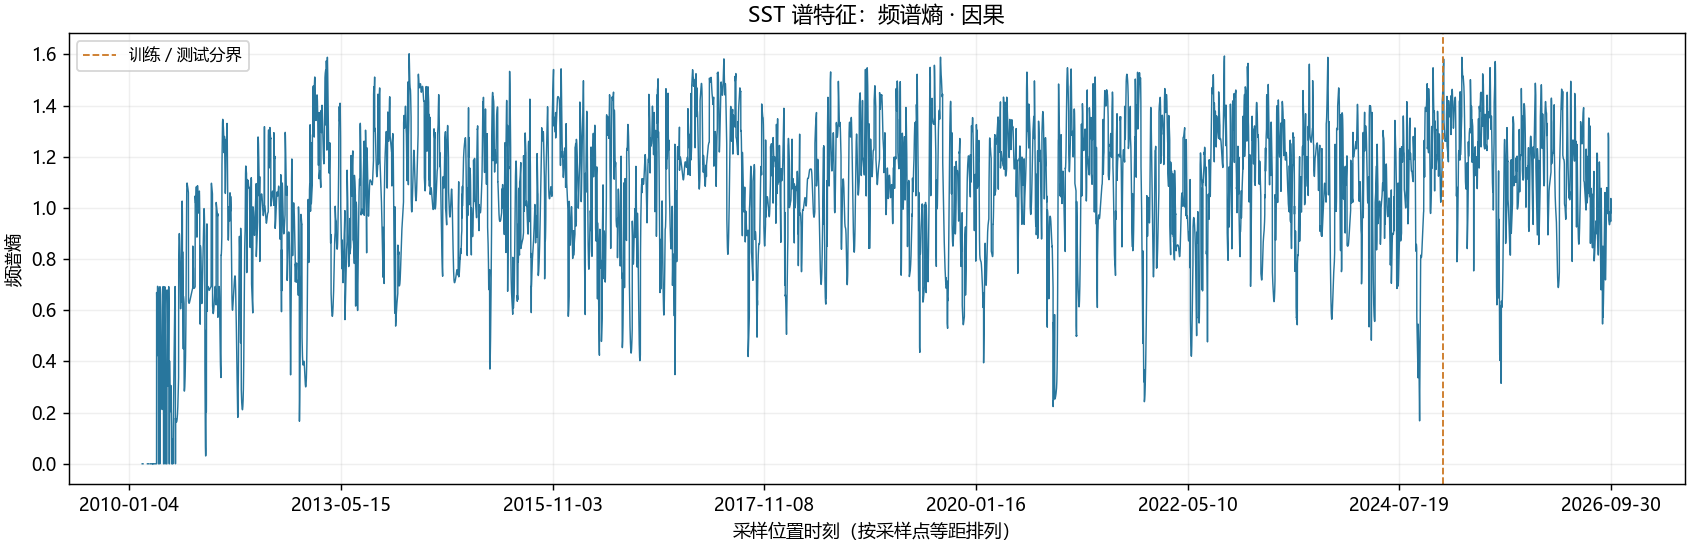

In [8]:
from IPython.display import display, Image
from io import BytesIO
import matplotlib.pyplot as plt

demo_preview_columns = ['sample_id','sample_at','sample_side','feature_available_at',
    'centroid','dominant_period_samples','spectral_entropy','phase_coherence','defined_feature_count','feature_status','feature_reason']
for demo_kind,demo_result in demo_results.items():
    print(f'核类型：{demo_kind}')
    display(demo_result['feature_df'][demo_preview_columns].tail(8)
        .rename(columns=SPECTRAL_FEATURE_COLUMN_LABELS).rename_axis('row（完整序列末端行）'))
    display(demo_result['feature_df'].groupby(['sst_status','feature_status','feature_reason'],dropna=False).size().rename('采样点数').reset_index()
        .rename(columns=SPECTRAL_FEATURE_COLUMN_LABELS).rename_axis('row（完整真实状态汇总行）'))
demo_plot_parameters = dict(plot_type='spectral_entropy',x_labels='sample_at')
demo_figure,demo_axes = plot_spectral_features(demo_results['causal_gammatone']['feature_df'],**demo_plot_parameters)
demo_png_buffer = BytesIO()
demo_figure.savefig(demo_png_buffer,format='png',dpi=130)
demo_plot_source = '\n\n'.join(''.join(c['source']) for c in demo_source_book['cells']
    if c['cell_type']=='code' and ''.join(c['source']).lstrip().startswith('def plot_spectral_features'))
demo_figure_identity = dict(source_path=demo_output_paths['causal_gammatone'].relative_to(candidate_root).as_posix(),
    source_content_sha256=demo_installed_identities['causal_gammatone']['output_content_sha256'],
    source_method_sha256=demo_method_source_sha256,
    plot_source_sha256=hashlib.sha256(demo_plot_source.encode()).hexdigest(),parameters=demo_plot_parameters)
display(Image(data=demo_png_buffer.getvalue()),metadata={'spectral_feature_figure_identity':demo_figure_identity})
plt.close(demo_figure)
print('完整真实谱特征 demo 与一张独立特征图已完成。',flush=True)


## 实际验收状态

2026-10-07 已在 `latitude_env_v2` 执行全部代码单元格，直接消费两种核的完整 RB SST 序列表，各提取 21,316 点、17 项指标。因果状态为 16,055 个 ok、4,982 个 partial、186 个 warmup、92 个 degenerate、1 个 failed；Morlet 为 17,403 个 ok、3,743 个 partial、124 个 boundary_incomplete、45 个 degenerate、1 个 failed。两个 failed 均继承上游首个收益率缺失，退化点为已有零谱，没有新增数值失败。

完整真实 demo 已实际调用纯谱入口、功率矩权重、区间等权和 partial 排除；平方范数、概率归一、特征范围、连续分块、训练前缀不变与可得时刻校验通过。两份 21,316 行特征表已保存并复读核对 Schema、生成身份和内容摘要。默认仅一张完整因果谱熵图，图像 metadata 记录数据与绘图来源。

14 项独立解析与边界测试通过，涵盖非均匀网格、圆周相位、权重、尺度不变性、零谱、单频、零分母、分位边界、数值极值、Schema 往返和无重算单图。临时测试 `R00_draft_collection_02/tests/test_spectral_features.py` 适合回归；构建／执行工具 `R00_draft_collection_02/scripts/*spectral_features*` 不作为正式算法入口，去留及最终归属待用户确认。